In [1]:
from ccka.models.kernel import KernelModel
from ccka.circuits.angleEmbeddingKernel import quackEmbeddingCircuit
from ccka.aligner.kta import fullKTA, centroidBasedKTA, quackKTA, randomKTA, greedyKTA
import pennylane as qml
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt 
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import time
import os
import warnings
warnings.filterwarnings("ignore")

/Users/digvijaysinhajarekar/Study/CCKA-Clustered_Centroid_Kernel_Alignment/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/digvijaysinhajarekar/Study/CCKA-Clustered_Centroid_Kernel_Alignment/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_data(dataset_path):
    data = jnp.load(dataset_path, allow_pickle=True).item()
    X = jnp.asarray(data['x_train'])
    y = jnp.asarray(data['y_train'])
    x_test = jnp.asarray(data['x_test'])
    y_test = jnp.asarray(data['y_test'])

    X_combined = jnp.concatenate([X, x_test], axis=0)
    y_combined = jnp.concatenate([y, y_test], axis=0)

    return X_combined, y_combined

In [3]:
config = {
    'zero_vs_nonzero': {   
        'qubits': 5,
        'reps': 3,
        'centroids': 12,
        'iterations': 500,
        'lr': 2.0
    },
    'one_vs_nonone': {   
        'qubits': 5,
        'reps': 3,
        'centroids': 12,
        'iterations': 500,
        'lr': 2.0
    },
    'adult': {
        'qubits': 5,
        'reps': 6,
        'centroids': 8,
        'iterations': 500,
        'lr': 1.0
    },
    'pfault': {
        'qubits': 6,
        'reps': 5,
        'centroids': 8,
        'iterations': 500,
        'lr': 1.0
    }
}

In [4]:
def run_experiment(method, dataset, dataset_path, config):

    print(f"Running {method} on {dataset} with centroids={config['centroids']} and iterations={config['iterations']}")

    centroids = config['centroids']
    num_iterations = config['iterations']
    reps = config['reps']
    lr = config['lr']
    nqubits = config['qubits']
    
    X, y = load_data(dataset_path)

    print('Labels: ', jnp.unique(y))
    print('Label Counts: ', jnp.bincount(y))

    kernel = quackEmbeddingCircuit(
                                num_qubits = nqubits,
                                reps = 3,
                                reupload = True
                        )

    print('Dataset Size: ', len(X))
    print('Qubits: ', X.shape[1])

    init_weights = kernel.init_weights()
    model = KernelModel(circuit = kernel)

    if method == 'fullKTA':
        aligner = fullKTA(
            kernel_model= model,
            data = X,
            labels = y,
            matrix_type='regular',
            split_size=0.8,
            learning_rate=0.1,
            optimizer= 'adam',
            epochs=num_iterations
        )
    
    elif method == 'centroidBasedKTA':
        print('Centroids: ', centroids)
        aligner = centroidBasedKTA(
                    kernel_model= model,
                    data = X,
                    labels = y,
                    matrix_type='regular',
                    clustering='regular',
                    split_size=0.80,
                    centroids= centroids,
                    learning_rate=lr,
                    centroid_lr=1.0,
                    sub_centroid_lr=1.0,
                    lambda_co=0.001,
                    lambda_kao=0.001,
                    epochs=num_iterations,
        )
    
    elif method == 'greedyKTA':
        print('Centroids: ', centroids)
        aligner = greedyKTA(
                    kernel_model= model,
                    data = X,
                    labels = y,
                    matrix_type='regular',
                    split_size=0.80,
                    greedy_samples= centroids,
                    landmark_points= 10,
                    learning_rate=0.1,
                    optimizer= 'adam',
                    epochs=num_iterations
        )
    
    elif method == 'randomKTA':
        print('Centroids: ', centroids)
        aligner = randomKTA(
                    kernel_model= model,
                    data = X,
                    labels = y,
                    matrix_type='regular',
                    split_size=0.80,
                    random_samples= centroids,
                    landmark_points=10,
                    learning_rate=0.1,
                    optimizer= 'adam',
                    epochs=num_iterations
        )
    elif method == 'quackKTA':
        print('Centroids: ', centroids)
        aligner = quackKTA(
                    kernel_model= model,
                    data = X,
                    labels = y,
                    matrix_type='regular',
                    clustering='regular',
                    split_size=0.50,
                    centroids= centroids,
                    lambda_co=0.001,
                    lambda_kao=0.001,
                    epochs=num_iterations,
                    eps=0.001,
                    alpha=0.01
        )

    history = aligner.align()

    result = {
        'method': method,
        'dataset': dataset,
        'centroids': centroids,
        'num_iterations': num_iterations,
        'initial_training_accuracy': history['init_train_accuracy'],
        'final_training_accuracy': history['train_accuracy_history'][-1],
        'initial_testing_accuracy': history['init_test_accuracy'],
        'final_testing_accuracy': history['test_accuracy_history'][-1],
        'f1_score': history['f1_score_history'][-1],
        'precision': history['precision_score_history'][-1],
        'recall': history['recall_score_history'][-1],
        'training_time': history['time'],
        'circuit_executions': history['circuit_executions'],
        'initial_kernel_alignment': history['alignment_history'][0],
        'final_kernel_alignment': history['alignment_history'][-1]
    }

    return result

In [5]:
# ── global matplotlib style (publication-ready) ───────────────────────────
import matplotlib as mpl
mpl.rcParams.update({
    'font.family':           'serif',
    'font.serif':            ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset':      'stix',
    'axes.labelsize':        14,
    'axes.titlesize':        14,
    'xtick.labelsize':       13,
    'ytick.labelsize':       13,
    'legend.fontsize':       12,
    'legend.title_fontsize': 12,
    'figure.dpi':            600,
    'savefig.dpi':           600,
    'axes.linewidth':        0.8,
    'xtick.major.width':     0.8,
    'ytick.major.width':     0.8,
    'xtick.minor.width':     0.5,
    'ytick.minor.width':     0.5,
    'lines.linewidth':       1.6,
    'patch.linewidth':       0.6,
})

# ── publication color palette (colorblind-safe, print-safe) ───────────────
# Based on Paul Tol's colorblind-safe palette
METHOD_STYLES = {
    'fullKTA': {
        'color':     '#0077BB',    # blue
        'marker':    'o',
        'linestyle': '-',
        'bar_color': '#0077BB',
        'hatch':     '',
    },
    'centroidBasedKTA': {
        'color':     '#EE7733',    # orange
        'marker':    's',
        'linestyle': '--',
        'bar_color': '#EE7733',
        'hatch':     '//',
    },
    'randomKTA': {
        'color':     '#009988',    # teal
        'marker':    '^',
        'linestyle': '-.',
        'bar_color': '#009988',
        'hatch':     'xx',
    },
    'greedyKTA': {
        'color':     '#CC3311',    # vermillion
        'marker':    'D',
        'linestyle': ':',
        'bar_color': '#CC3311',
        'hatch':     '\\\\',
    },
    'quackKTA': {
        'color':     '#AA3377',    # magenta/purple
        'marker':    'v',
        'linestyle': (0, (3, 1, 1, 1)),   # densely dash-dotted
        'bar_color': '#AA3377',
        'hatch':     '..',
    },
}

# Fallback styles for unexpected extra methods
_EXTRA_STYLES = [
    {'color': '#BBBBBB', 'marker': 'p', 'linestyle': '-',  'bar_color': '#BBBBBB', 'hatch': ''},
    {'color': '#44BB99', 'marker': 'h', 'linestyle': '--', 'bar_color': '#44BB99', 'hatch': '//'},
    {'color': '#AAAA00', 'marker': '*', 'linestyle': ':',  'bar_color': '#AAAA00', 'hatch': 'xx'},
]

INITIAL_BAR_COLOR = '#4477AA'   # darker blue  — "Initial"
FINAL_BAR_COLOR   = '#EE6677'   # muted red    — "Final"


# ── accuracy summary panel ──────────────────────────────────────────────────

_ALL_METHODS = ['fullKTA', 'randomKTA', 'quackKTA', 'centroidBasedKTA', 'greedyKTA']

_INITIAL_STYLE = dict(color='#aaaaaa', hatch='////')


def plot_accuracy_summary_panel(final_results, datasets, figsize=(11, 4)):
    """
    Single horizontal grouped-bar chart:
    • Y-axis  – one row per dataset
    • Bars    – one bar per method  +  one 'Initial (avg)' reference bar
    • Values  – final_testing_accuracy averaged over ALL iterations
                and ALL centroid counts (so centroid-based methods and
                fullKTA are treated uniformly)
    • Initial – initial_training_accuracy averaged over all methods
                per dataset (omitted silently if the key is absent)

    Parameters
    ----------
    final_results : list[dict]
        Output of run_experiment(). Required keys:
            'method', 'dataset', 'final_testing_accuracy'
        Optional key:
            'initial_testing_accuracy'
    datasets : list[str]
        Ordered dataset names — controls row order top → bottom.
    figsize : tuple
        Overall figure size in inches.
    """
    df = pd.DataFrame(final_results)

    # ── aggregate final accuracy (method × dataset) ───────────────────────
    df_final = (
        df.groupby(['method', 'dataset'])['final_testing_accuracy']
        .max()
        .reset_index()
    )

    # ── aggregate initial accuracy (dataset only) ─────────────────────────
    has_initial = 'initial_testing_accuracy' in df.columns
    if has_initial:
        df_init = (
            df.groupby('dataset')['initial_testing_accuracy']
            .mean()
            .reset_index()
        )

    # ── bar layout ────────────────────────────────────────────────────────
    methods_present = [m for m in _ALL_METHODS if m in df['method'].unique()]
    bar_labels      = (['Initial (avg)'] if has_initial else []) + methods_present
    n_bars          = len(bar_labels)
    bar_h           = 0.72 / n_bars          # total cluster height = 0.72

    # ── figure ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize, facecolor='white')

    for row_idx, dataset in enumerate(datasets):
        for bar_idx, label in enumerate(bar_labels):

            # vertical offset so bars fan symmetrically around row centre
            offset = (bar_idx - (n_bars - 1) / 2.0) * bar_h
            y_pos  = row_idx + offset

            # ── value & style ─────────────────────────────────────────
            if label == 'Initial (avg)':
                sub = df_init[df_init['dataset'] == dataset]
                val = float(sub['initial_testing_accuracy']) \
                      if not sub.empty else 0.0
                color = _INITIAL_STYLE['color']
                hatch = _INITIAL_STYLE['hatch']
                ec    = 'white'
            else:
                sub = df_final[
                    (df_final['method']  == label) &
                    (df_final['dataset'] == dataset)
                ]
                val   = float(sub['final_testing_accuracy'].iloc[0]) \
                        if not sub.empty else 0.0
                sty   = METHOD_STYLES.get(label, {})
                color = sty.get('color', '#888888')
                hatch = None
                ec    = 'white'

            ax.barh(
                y_pos, val,
                height   = bar_h * 0.82,
                color    = color,
                hatch    = hatch,
                edgecolor= ec,
                linewidth= 0.6,
                alpha    = 0.90,
            )

            # inline value label
            ax.text(
                val + 0.007, y_pos,
                f'{val:.2f}',
                va='center', ha='left',
                fontsize=7.5,
                color='#444444',
            )

    # ── axes ──────────────────────────────────────────────────────────────
    ax.set_yticks(range(len(datasets)))
    ax.set_yticklabels(datasets, fontsize=10, fontweight='bold')
    ax.invert_yaxis()                        # top dataset first

    ax.set_xlim(0, 1.18)
    ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_xlabel('Accuracy', fontsize=10)
    ax.set_title(
        'Final Test Accuracy by Dataset & Method\n'
        '(averaged over all iterations and centroid counts)',
        fontsize=12, fontweight='bold', pad=10,
    )

    ax.grid(axis='x', linestyle=':', linewidth=0.6, alpha=0.6)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', length=0)

    # ── legend ────────────────────────────────────────────────────────────
    handles = []
    if has_initial:
        handles.append(
            mpl.patches.Patch(
                facecolor=_INITIAL_STYLE['color'],
                hatch=_INITIAL_STYLE['hatch'],
                edgecolor='white', alpha=0.90,
                label='Initial (avg)',
            )
        )
    for m in methods_present:
        sty = METHOD_STYLES.get(m, {})
        handles.append(
            mpl.patches.Patch(
                facecolor=sty.get('color', '#888888'),
                alpha=0.90,
                label=m,
            )
        )

    ax.legend(
        handles=handles,
        fontsize=8,
        loc='lower right',
        framealpha=0.85,
        edgecolor='#cccccc',
        frameon=True,
        title='Method',
        title_fontsize=8,
    )

    fig.tight_layout()

    for fmt in ('png', 'pdf'):
        fig.savefig(f'kta_accuracy_summary.{fmt}',
                    dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print("Saved: kta_accuracy_summary.png  /  kta_accuracy_summary.pdf")

In [6]:
# Experiment Configuration
datasets = ['zero_vs_nonzero', 'one_vs_nonone', 'adult', 'pfault']
dataset_paths = {
    'zero_vs_nonzero': '../data/zero_vs_nonzero.npy',
    'one_vs_nonone': '../data/one_vs_nonone.npy',
    'adult': '../data/adult.npy',
    'covtype': '../data/covtype.npy',
    'pfault': '../data/pfault.npy'
}
methods = ['fullKTA', 'randomKTA', 'quackKTA', 'centroidBasedKTA', 'greedyKTA'] 
_CENTROID_METHODS = ['centroidBasedKTA', 'randomKTA', 'greedyKTA', 'quackKTA']

In [7]:
# Run Experiments
final_results = []
for dataset in datasets:
    for method in methods:
        if method == 'fullKTA':
            result = run_experiment(method, dataset, dataset_paths[dataset], config[dataset])
            final_results.append(result)
        else:
            result = run_experiment(method, dataset, dataset_paths[dataset], config[dataset])
            final_results.append(result)

Running fullKTA on zero_vs_nonzero with centroids=12 and iterations=500
Labels:  [-1  1]
Label Counts:  [50 50]
Dataset Size:  100
Qubits:  4
Running randomKTA on zero_vs_nonzero with centroids=12 and iterations=500
Labels:  [-1  1]
Label Counts:  [50 50]
Dataset Size:  100
Qubits:  4
Centroids:  12
Running quackKTA on zero_vs_nonzero with centroids=12 and iterations=500
Labels:  [-1  1]
Label Counts:  [50 50]
Dataset Size:  100
Qubits:  4
Centroids:  12
Running centroidBasedKTA on zero_vs_nonzero with centroids=12 and iterations=500
Labels:  [-1  1]
Label Counts:  [50 50]
Dataset Size:  100
Qubits:  4
Centroids:  12
Running greedyKTA on zero_vs_nonzero with centroids=12 and iterations=500
Labels:  [-1  1]
Label Counts:  [50 50]
Dataset Size:  100
Qubits:  4
Centroids:  12
Running fullKTA on one_vs_nonone with centroids=12 and iterations=500
Labels:  [-1  1]
Label Counts:  [50 50]
Dataset Size:  100
Qubits:  4
Running randomKTA on one_vs_nonone with centroids=12 and iterations=500
Labe

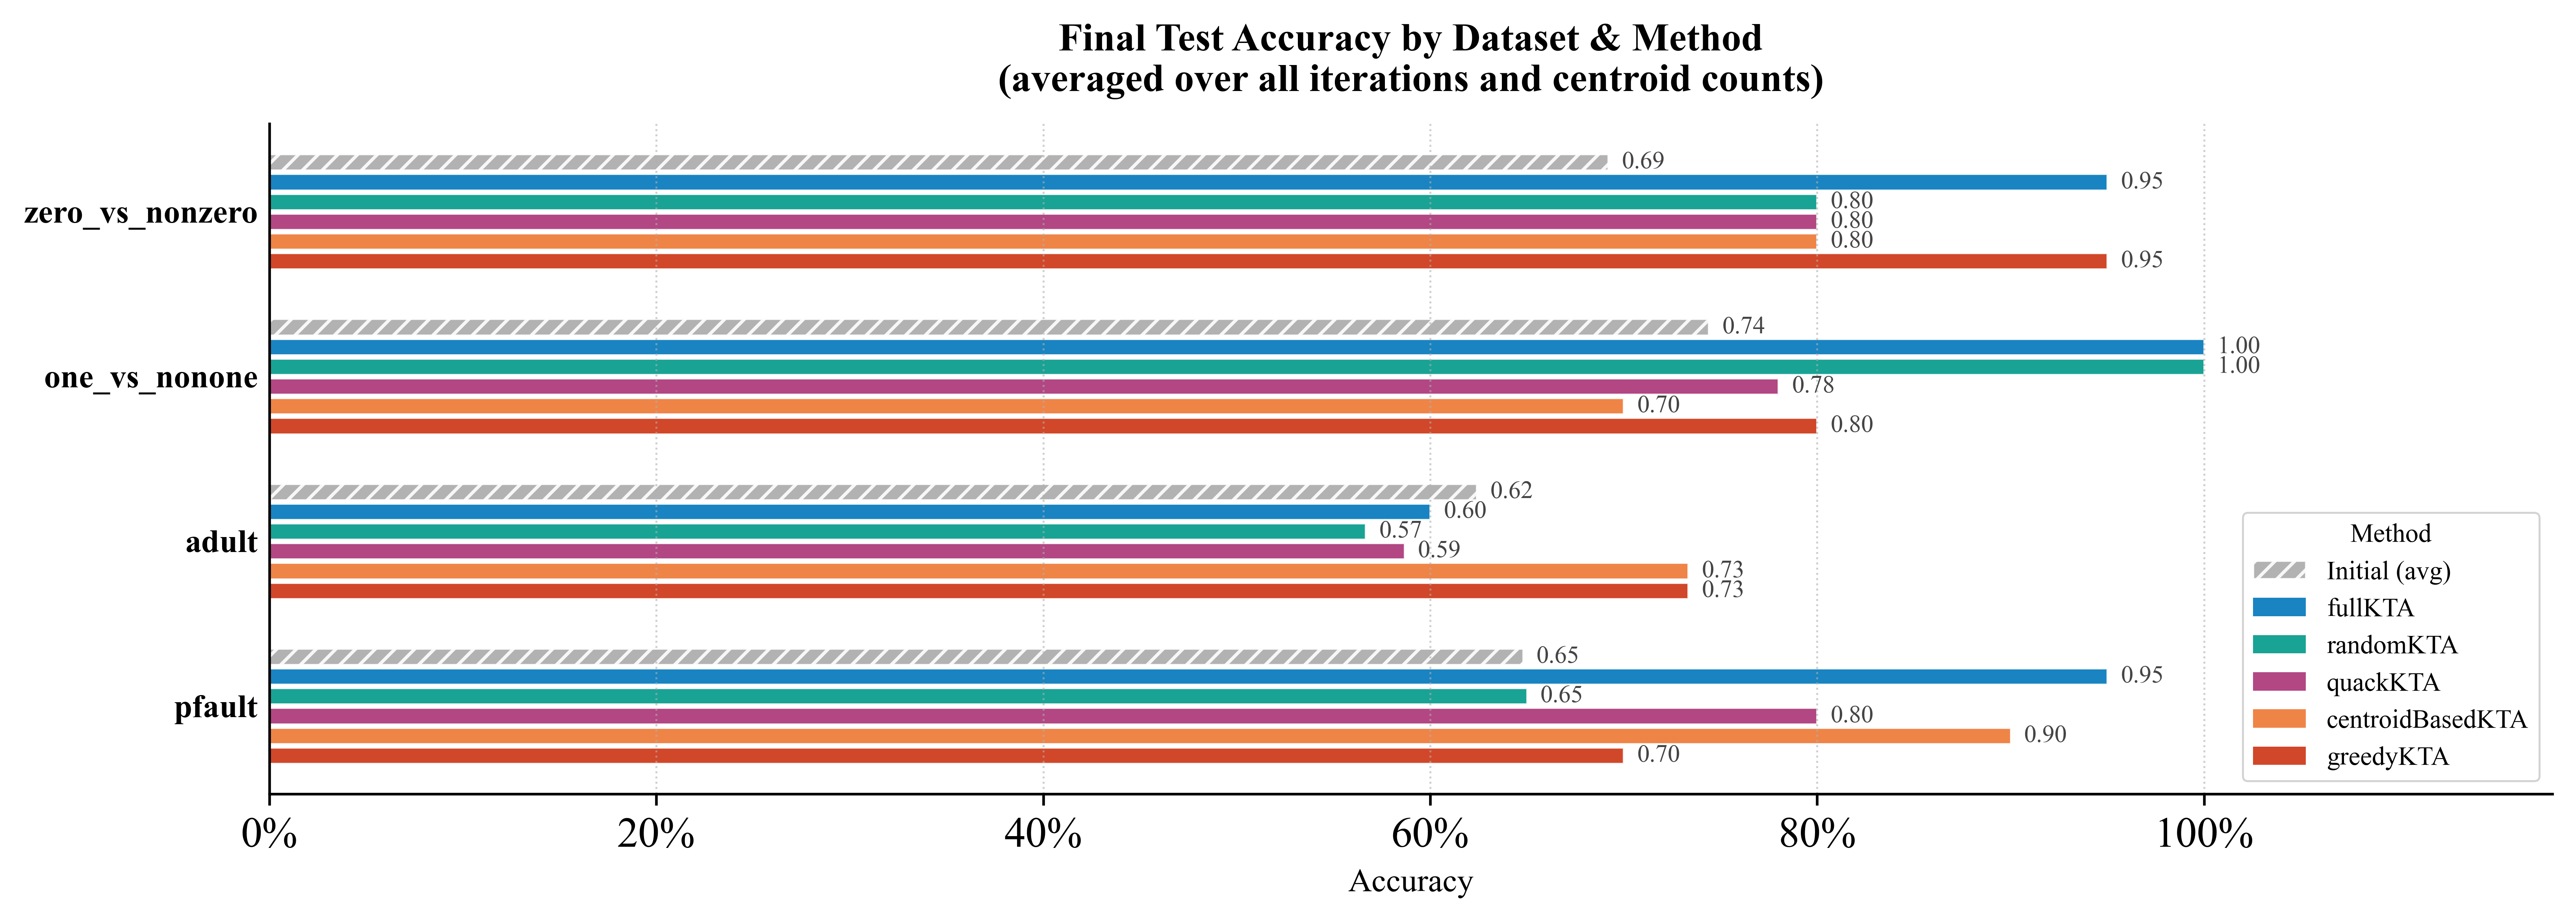

Saved: kta_accuracy_summary.png  /  kta_accuracy_summary.pdf


In [8]:
plot_accuracy_summary_panel(final_results, datasets)